In [1]:
from astropy.io import fits,ascii
from glob import glob
from astropy.table import Table, vstack
import numpy as np
import plotfancy as pf
import seaborn as sns
pf.housestyle_rcparams()
from matplotlib.pyplot import get_cmap
import matplotlib.pyplot as plt

from astropy.cosmology import Planck18 as cosmo
from astropy.cosmology.funcs import z_at_value
import astropy.units as u
import matplotlib.ticker as mticker

In [2]:
def clean_table(input):
    output = input[input['Redshift']!=0]
    return output.group_by('ID')

In [3]:
clustable = ascii.read('clusters.csv')
clustable.add_index('key')

cats = glob('newcats/*.cat')

with fits.open(cats[4]) as f:
    starter = Table(f[1].data)

master = clean_table(starter)

catkeys = [] 
for c in cats[1:]:
    catkeys.append(c[8:][0:-9])

for i, c in enumerate(cats):
    ky = c[8:-9]
    with fits.open(c) as f:
        raw = Table(f[1].data)
    clean = clean_table(raw)

    cluster_row = clustable.loc[ky]

    clean['key'] = ky
    clean['cluster'] = cluster_row['cluster']
    clean['zcluster'] = cluster_row['z'] if cluster_row['z'] != 0 else np.nan
    clean['dir'] = cluster_row['directory']

    master = vstack([master,clean])

lead_lines = []
test = master.group_by('ID')
for t in test.groups:
    arg = np.argmax(t['DETSN_MAX'])
    lead_lines.append(t[arg])

lead_lines_tab = vstack(lead_lines)
lead_lines_tab.write('leadlines.csv', overwrite=True)

In [4]:
lead_lines_tab

I,ID,X_PEAK_SN,Y_PEAK_SN,Z_PEAK_SN,DETSN_MAX,Identification,Short,Comment,Redshift,Quality,Confidence,Association,key,cluster,zcluster,dir
int16,int64,float32,float32,float32,float64,str20,str10,str8,float64,str10,str10,str10,str12,str17,float64,str9
167,1,95.0,19.0,1209.0,9.169170379638672,Lya,Lya,-,4.15162,c,0,-,a209,A209,0.2048,cubes
5231,3,300.0,197.0,3253.0,8.984107971191406,OIII 2,O3_2,-,0.76085,c,0,-,macs0033m07,MACS0035.4-2015,0.352,cubes
1077,4,19.0,176.0,2961.0,37.767879486083984,Lya,Lya,-,5.954,a,3,-,a141,Abell141,0.23,cubes
1708,6,160.0,15.0,1205.0,12.623516082763672,OIII 2,O3_2,-,0.24946,a,3,-,macs0159m34,MACSJ0159.0-3413,nan,cubes
1093,7,132.0,194.0,2635.0,106.42247009277344,Ha,Ha,-,0.22569,a,3,-,a141,Abell141,0.23,cubes
3213,9,236.0,31.0,426.0,8.06135368347168,Lya,Lya,-,3.34665,c,0,-,macs0027p26a,MACS0027.2+2607,nan,cubes
786,13,83.0,25.0,3222.0,9.553396224975586,Lya,Lya,-,6.22203,c,0,-,macs0449m28,MACSJ0449.3-2848,nan,cubes_new
1113,15,169.0,56.0,2584.0,35.25693130493164,Ha,Ha,-,0.21597,a,3,-,a141,Abell141,0.23,cubes
4858,17,267.0,52.0,2190.0,8.226968765258789,OIII 2,O3_2,-,0.49537,c,0,-,macs0257m23,MACSJ0257.1-2325,0.5049,cubes_new


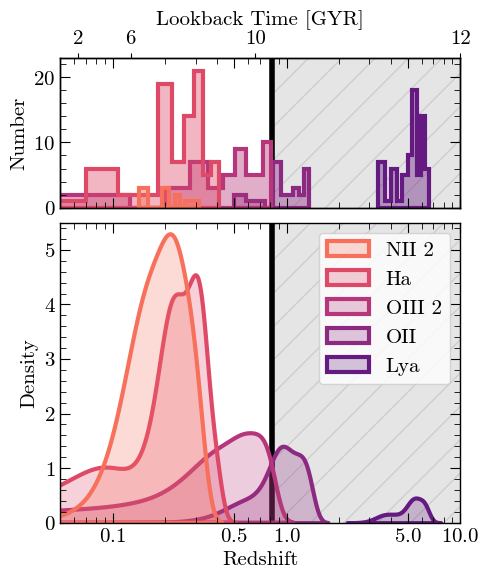

In [5]:
lead_lines_tab.sort('Redshift')
groups_lines = lead_lines_tab.group_by('Short')

all_groups = list(groups_lines.groups)
sorted_groups = sorted(all_groups, key=lambda g: np.mean(g['Redshift']))
groups_to_plot = [g for g in sorted_groups if len(g) > 4]
num_plots = len(groups_to_plot)


fig, ax = pf.create_plot()
ax2 = fig.add_axes((0,1.05,1,0.5),sharex=ax)
axes = [ax,ax2]

cmap = get_cmap('magma_r')
points = np.linspace(0.3,0.7,num_plots)
rgba_colors = cmap(points)
i=0

for i, g in enumerate(groups_to_plot):
    line = g['Identification'][0]
    sns.kdeplot(x=g['Redshift'], ax=ax, linewidth=3, color=rgba_colors[i], label=line, fill='layer', zorder=-i)

    fc = [rgba_colors[i][0],rgba_colors[i][1],rgba_colors[i][2],0.4]

    ax2.hist(g['Redshift'], facecolor=fc, histtype='stepfilled', lw=3, edgecolor=rgba_colors[i], zorder=-i)

ax.set_xscale('log', base=10)
ax.set_xlim(0.05,10)

ax2.set_ylabel('Number')
ax.legend()

tick_locations = [0.1,0.5, 1, 5, 10]
ax.set_xticks(tick_locations)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())

ax3 = ax2.twiny()
lookback_time_ticks_gyr = [2, 6, 10, 12]
z_for_ticks = [z_at_value(cosmo.lookback_time, t * u.Gyr) for t in lookback_time_ticks_gyr]
ax3.set_xticks(z_for_ticks)
ax3.set_xticklabels([f'{t}' for t in lookback_time_ticks_gyr])
ax3.set_xlabel('Lookback Time [GYR]')
plt.setp(ax2.get_xticklabels(), visible=False)

ax.set_ylim(0,5.5)
ax2.set_ylim(0,23)

for a in axes:
    a.vlines(0.83, -100,100, colors='k', lw=4,zorder=-10)
    a.fill_betweenx([-100,100],0.83,100, zorder=-100, color='k', alpha=0.1, hatch='/', edgecolor='k')


pf.fix_plot(axes)
fig.savefig(f'figs/zdist_new.png', dpi=600, bbox_inches='tight')

In [6]:
lead_lines_tab

I,ID,X_PEAK_SN,Y_PEAK_SN,Z_PEAK_SN,DETSN_MAX,Identification,Short,Comment,Redshift,Quality,Confidence,Association,key,cluster,zcluster,dir
int16,int64,float32,float32,float32,float64,str20,str10,str8,float64,str10,str10,str10,str12,str17,float64,str9
4996,138,273.0,224.0,756.0,16.72516441345215,-,-,-,-0.13227,-,0,-,macs0449m28,MACSJ0449.3-2848,nan,cubes_new
9704,112,155.0,266.0,1623.0,38.883392333984375,Ha,Ha,-,0.03284,a,3,-,macs0404p11,MACSJ0404.6+1109,0.3548,cubes_new
8909,29,110.0,101.0,400.0,72.85591125488281,OIII 2,O3_2,-,0.04852,c,0,-,macs0547m39,MACS0547.0-3904,0.3142,cubes_new
9407,247,264.0,222.0,1876.0,9.173638343811035,Ha,Ha,-,0.08105,c,0,-,z2089,Zw2089,nan,cubes_new
9118,122,255.0,231.0,1876.0,40.883541107177734,Ha,Ha,-,0.08105,c,0,-,z2089,Zw2089,nan,cubes_new
9408,248,262.0,245.0,1877.0,10.07020378112793,Ha,Ha,-,0.08124,c,0,-,z2089,Zw2089,nan,cubes_new
9409,249,254.0,248.0,1877.0,8.544206619262695,Ha,Ha,-,0.08124,c,0,-,z2089,Zw2089,nan,cubes_new
9414,251,242.0,252.0,1879.0,9.175813674926758,Ha,Ha,-,0.08163,a,3,-,z2089,Zw2089,nan,cubes_new
9416,252,246.0,263.0,1879.0,8.462374687194824,Ha,Ha,-,0.08163,a,3,-,z2089,Zw2089,nan,cubes_new
